In [7]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

print("all good!")

all good!


In [8]:
# loading the stock prices dataset
df = pd.read_csv('2) Stock Prices Data Set.csv')

print("first 5 rows:")
print(df.head())
print()
print("shape:", df.shape)
print()
print("columns:")
print(df.columns.tolist())
print()
print("missing values:")
print(df.isnull().sum())

first 5 rows:
  symbol        date      open      high       low     close    volume
0    AAL  2014-01-02   25.0700   25.8200   25.0600   25.3600   8998943
1   AAPL  2014-01-02   79.3828   79.5756   78.8601   79.0185  58791957
2    AAP  2014-01-02  110.3600  111.8800  109.2900  109.7400    542711
3   ABBV  2014-01-02   52.1200   52.3300   51.5200   51.9800   4569061
4    ABC  2014-01-02   70.1100   70.2300   69.4800   69.8900   1148391

shape: (497472, 7)

columns:
['symbol', 'date', 'open', 'high', 'low', 'close', 'volume']

missing values:
symbol     0
date       0
open      11
high       8
low        8
close      0
volume     0
dtype: int64


In [9]:
# stock prices - we want to predict if the price went up or down
# classic binary classification problem
# 1 = price went up, 0 = price went down

df = df.dropna()  # drop the few missing rows, only 11 out of 497k so no big deal

# create our target column - did the price go up from open to close?
df['target'] = (df['close'] > df['open']).astype(int)

print("price went up:", df['target'].sum())
print("price went down:", (df['target'] == 0).sum())
print()
print(df.head())

price went up: 255779
price went down: 241682

  symbol        date      open      high       low     close    volume  target
0    AAL  2014-01-02   25.0700   25.8200   25.0600   25.3600   8998943       1
1   AAPL  2014-01-02   79.3828   79.5756   78.8601   79.0185  58791957       0
2    AAP  2014-01-02  110.3600  111.8800  109.2900  109.7400    542711       0
3   ABBV  2014-01-02   52.1200   52.3300   51.5200   51.9800   4569061       0
4    ABC  2014-01-02   70.1100   70.2300   69.4800   69.8900   1148391       0


In [10]:
# features are the daily price movements
# dropping symbol and date since they are not numbers
X = df[['open', 'high', 'low', 'volume']]
y = df['target']

# scale everything - svm is very sensitive to scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 80/20 split as usual
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("training size:", X_train.shape)
print("testing size:", X_test.shape)

training size: (397968, 4)
testing size: (99493, 4)


In [11]:
# svm struggles with huge datasets so we take a sample of 5000 rows
# this is normal practice - no need to use all 497k rows
df_sample = df.sample(n=5000, random_state=42)

X = df_sample[['open', 'high', 'low', 'volume']]
y = df_sample['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("training size:", X_train.shape)
print("testing size:", X_test.shape)

training size: (4000, 4)
testing size: (1000, 4)


In [12]:
# training two svm models with different kernels
# linear draws a straight boundary, rbf draws curved ones

svm_linear = SVC(kernel='linear', random_state=42, probability=True)
svm_linear.fit(X_train, y_train)
pred_linear = svm_linear.predict(X_test)

svm_rbf = SVC(kernel='rbf', random_state=42, probability=True)
svm_rbf.fit(X_train, y_train)
pred_rbf = svm_rbf.predict(X_test)

print("both models trained!")

both models trained!


In [13]:
# comparing the two kernels side by side
print("LINEAR KERNEL RESULTS:")
print(classification_report(y_test, pred_linear))

print("RBF KERNEL RESULTS:")
print(classification_report(y_test, pred_rbf))

LINEAR KERNEL RESULTS:
              precision    recall  f1-score   support

           0       1.00      0.00      0.00       496
           1       0.50      1.00      0.67       504

    accuracy                           0.51      1000
   macro avg       0.75      0.50      0.34      1000
weighted avg       0.75      0.51      0.34      1000

RBF KERNEL RESULTS:
              precision    recall  f1-score   support

           0       0.63      0.06      0.11       496
           1       0.51      0.97      0.67       504

    accuracy                           0.52      1000
   macro avg       0.57      0.51      0.39      1000
weighted avg       0.57      0.52      0.39      1000



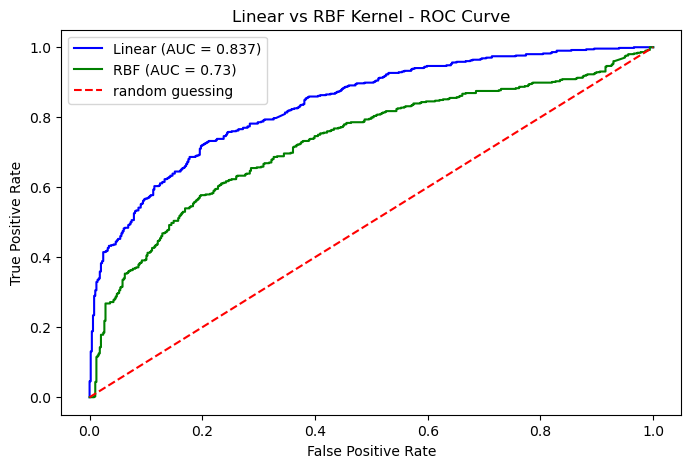

Linear AUC: 0.837
RBF AUC: 0.73


In [14]:
# roc curve for both models
# shows which kernel is better at telling up days from down days

fpr_l, tpr_l, _ = roc_curve(y_test, svm_linear.predict_proba(X_test)[:,1])
fpr_r, tpr_r, _ = roc_curve(y_test, svm_rbf.predict_proba(X_test)[:,1])

auc_linear = roc_auc_score(y_test, svm_linear.predict_proba(X_test)[:,1])
auc_rbf = roc_auc_score(y_test, svm_rbf.predict_proba(X_test)[:,1])

plt.figure(figsize=(8,5))
plt.plot(fpr_l, tpr_l, label=f'Linear (AUC = {round(auc_linear,3)})', color='blue')
plt.plot(fpr_r, tpr_r, label=f'RBF (AUC = {round(auc_rbf,3)})', color='green')
plt.plot([0,1],[0,1], 'r--', label='random guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Linear vs RBF Kernel - ROC Curve')
plt.legend()
plt.show()

print("Linear AUC:", round(auc_linear, 3))
print("RBF AUC:", round(auc_rbf, 3))

In [15]:
# 497k rows is way too much for svm - it would run for hours
# taking a random sample of 5000 rows instead
# this is actually common practice with svm on large datasets

df_sample = df.sample(n=5000, random_state=42)

# features and target
X = df_sample[['open', 'high', 'low', 'volume']]
y = df_sample['target']

# scale everything
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("training size:", X_train.shape)
print("testing size:", X_test.shape)

training size: (4000, 4)
testing size: (1000, 4)


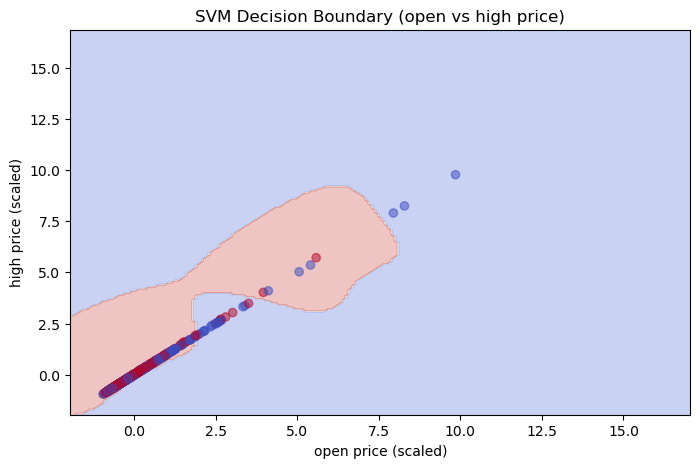

In [16]:
# decision boundary - showing how the model separates up days from down days
# using just 2 features so we can actually plot it in 2D

X_2d = df_sample[['open', 'high']].values
X_2d_scaled = StandardScaler().fit_transform(X_2d)
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(X_2d_scaled, y, test_size=0.2, random_state=42)

svm_plot = SVC(kernel='rbf', random_state=42)
svm_plot.fit(X_train_2d, y_train_2d)

x_min, x_max = X_2d_scaled[:, 0].min() - 1, X_2d_scaled[:, 0].max() + 1
y_min, y_max = X_2d_scaled[:, 1].min() - 1, X_2d_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

Z = svm_plot.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_test_2d[:,0], X_test_2d[:,1], c=y_test_2d, cmap='coolwarm', alpha=0.5)
plt.title('SVM Decision Boundary (open vs high price)')
plt.xlabel('open price (scaled)')
plt.ylabel('high price (scaled)')
plt.show()